# Band disentanglement with outer and frozen energy windows
A fixed band range can only be Wannierized when it is separated from the rest of the spectrum
by a gap over the whole Brillouin zone. The two $p_z$ bands of graphene are the simplest case
where this fails: they touch at the K points, so neither of them is a smooth subspace on its
own. Souza-Marzari-Vanderbilt disentanglement handles this case by extracting `num_wann`
optimally connected states out of a larger set of offered bands, k-point by k-point, and it is
switched on in `h.get_wannier_hamiltonian()` by passing a `num_wann` smaller than the number of
bands in `bands=[a,b]`. The states inside the frozen inner window (`dis_froz_min`,
`dis_froz_max`) are kept exactly at every k-point of the wannierization mesh, while outside it
the extracted subspace is a smoother combination of the offered bands rather than any one of
them. An outer window (`dis_win_min`, `dis_win_max`) narrows which states are offered at each
k-point, so that every eigenvalue of the resulting model lies inside it.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry

### One Wannier function out of the two bands of graphene
We offer both $p_z$ bands and ask for a single Wannier function, freezing the part of the
valence band below $E=-1$. Where the valence band lies inside the frozen window the Wannier
band follows it exactly; close to the K points, where the valence band rises into the Dirac
cone, the extracted state is a smooth mixture of both bands and the Wannier band departs
from the original one. The map below shows that difference over the whole Brillouin zone,
with the boundary of the frozen window drawn as a dashed contour. The warning printed by the
calculation says that the minimization of the spread did not converge within `dis_num_iter`
iterations (200 by default): the frozen window is reproduced either way, and a larger
`dis_num_iter` refines the rest.

../../../src/pyqula/wanniertk/wannierpy/_engine/__init__.py:163: UserWarning: backend='python': disentanglement did not converge within dis_num_iter=200 iterations (relative change of Omega_I above dis_conv_tol=1e-10); the frozen states are still reproduced exactly, pass a larger dis_num_iter for a converged subspace
  warnings.warn("backend='python': disentanglement did not converge within "


Wannier functions: 1
windows used: {'dis_win_min': None, 'dis_win_max': None, 'dis_froz_min': None, 'dis_froz_max': -1.0}
spread: [0.70784057]


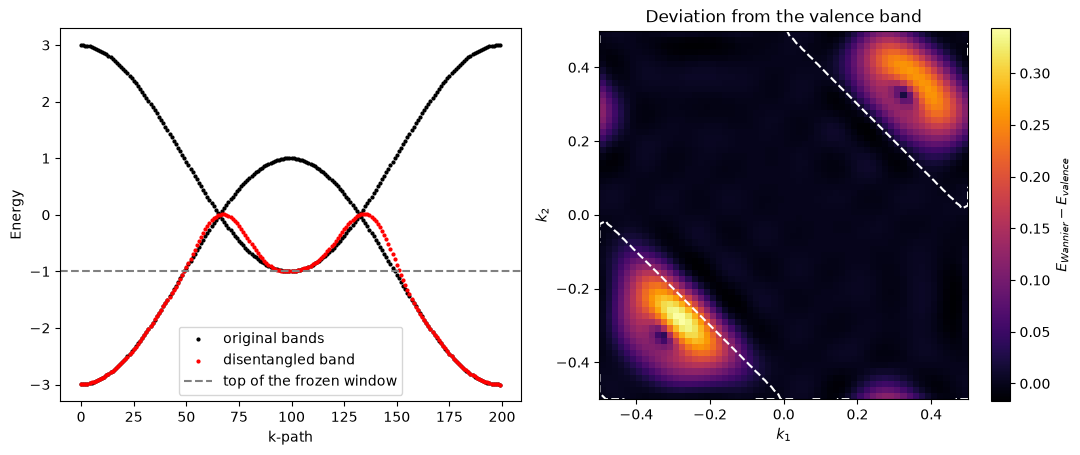

In [2]:
g = geometry.honeycomb_lattice()
h = g.get_hamiltonian(has_spin=False) # graphene pz bands, touching at K

# one Wannier function out of the two bands, the valence states below E=-1 frozen
hwan = h.get_wannier_hamiltonian(bands=[0,1],num_wann=1,nk=12,
                                 dis_froz_max=-1.0,cutoff=0.0)
print("Wannier functions:",hwan.wannier_num_wann)
print("windows used:",hwan.wannier_disentanglement_window)
print("spread:",hwan.wannier_spreads)

(k,e) = h.get_bands(nk=200,write=False) # original bands
(kw,ew) = hwan.get_bands(nk=200,write=False) # disentangled band

# difference between the Wannier band and the valence band over the Brillouin zone
f0,fw = h.get_hk_gen(),hwan.get_hk_gen()
nk = 60
ks = np.linspace(-0.5,0.5,nk) # fractional coordinates, Gamma at the center
dE = np.zeros((nk,nk)) ; ev = np.zeros((nk,nk))
for i,k1 in enumerate(ks):
    for j,k2 in enumerate(ks):
        e0 = np.linalg.eigvalsh(f0([k1,k2,0.]))[0] # valence band
        dE[j,i] = np.linalg.eigvalsh(fw([k1,k2,0.]))[0] - e0
        ev[j,i] = e0

fig,axs = plt.subplots(1,2,figsize=(11,4.5))
axs[0].scatter(k,e,c="black",s=4,label="original bands")
axs[0].scatter(kw,ew,c="red",s=4,label="disentangled band")
axs[0].axhline(-1.0,ls="--",c="gray",label="top of the frozen window")
axs[0].set_xlabel("k-path") ; axs[0].set_ylabel("Energy") ; axs[0].legend()
im = axs[1].imshow(dE,origin="lower",extent=[-0.5,0.5,-0.5,0.5],cmap="inferno")
axs[1].contour(ks,ks,ev,levels=[-1.0],colors="white",linestyles="--")
plt.colorbar(im,ax=axs[1],label="$E_{Wannier}-E_{valence}$")
axs[1].set_xlabel("$k_1$") ; axs[1].set_ylabel("$k_2$")
axs[1].set_title("Deviation from the valence band")
plt.tight_layout()
plt.show()

### How localized the disentangled Wannier function is
The real-space hoppings of the Wannier Hamiltonian, $t(\mathbf R)$, are the matrix elements
between the Wannier function in the home cell and its copy in the cell at
$\mathbf R = n_1\mathbf a_1+n_2\mathbf a_2$. Their magnitude falls off quickly with the
distance, by about two orders of magnitude over the first two or three cells, which is what a
localized Wannier function and a short-ranged model mean in practice; a small tail remains out
to the edge of the $12\times12$ mesh, since the function is built from bands that touch at K.

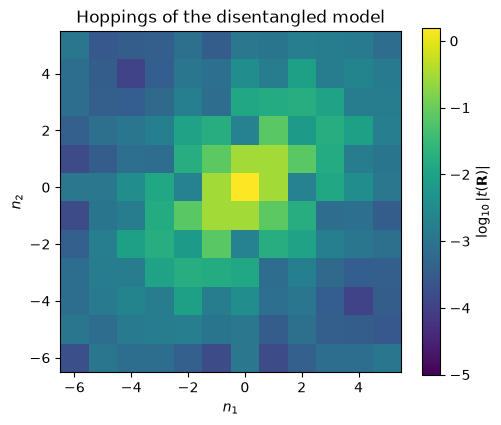

In [3]:
hops = hwan.get_multihopping().get_dict() # lattice vector -> hopping matrix
n1s = [int(R[0]) for R in hops] ; n2s = [int(R[1]) for R in hops]
tmap = np.full((max(n2s)-min(n2s)+1,max(n1s)-min(n1s)+1),np.nan)
for R,m in hops.items():
    tmap[int(R[1])-min(n2s),int(R[0])-min(n1s)] = np.abs(np.array(m)[0,0])

plt.figure(figsize=(5.5,4.5))
plt.imshow(np.log10(tmap+1e-16),origin="lower",cmap="viridis",vmin=-5,
           extent=[min(n1s)-0.5,max(n1s)+0.5,min(n2s)-0.5,max(n2s)+0.5])
plt.colorbar(label="$\\log_{10}|t(\\mathbf{R})|$")
plt.xlabel("$n_1$") ; plt.ylabel("$n_2$")
plt.title("Hoppings of the disentangled model")
plt.show()

### Adding an outer window
With `dis_win_max` the conduction states above $E=1$ are no longer offered, so at each k-point
the Wannier function is built only from the states below that energy. Inside the frozen window
nothing changes, since those states are kept exactly either way, while outside it, around the
K points, the disentangled band is a different mixture than in the calculation above, and every
eigenvalue of the model stays inside the outer window.

windows used: {'dis_win_min': None, 'dis_win_max': 1.0, 'dis_froz_min': None, 'dis_froz_max': -1.0}


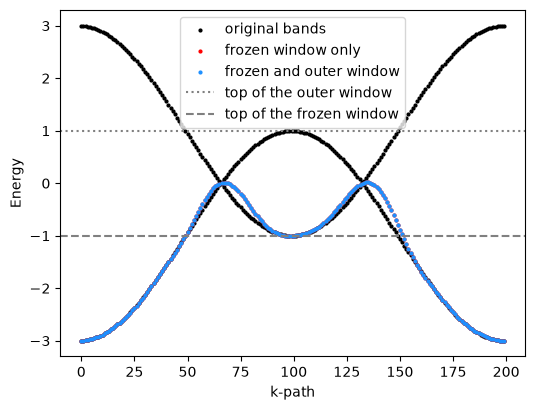

In [4]:
hwan2 = h.get_wannier_hamiltonian(bands=[0,1],num_wann=1,nk=12,
                                  dis_win_max=1.0,dis_froz_max=-1.0,cutoff=0.0)
print("windows used:",hwan2.wannier_disentanglement_window)
(kw2,ew2) = hwan2.get_bands(nk=200,write=False)

plt.figure(figsize=(6,4.5))
plt.scatter(k,e,c="black",s=4,label="original bands")
plt.scatter(kw,ew,c="red",s=4,label="frozen window only")
plt.scatter(kw2,ew2,c="dodgerblue",s=4,label="frozen and outer window")
plt.axhline(1.0,ls=":",c="gray",label="top of the outer window")
plt.axhline(-1.0,ls="--",c="gray",label="top of the frozen window")
plt.xlabel("k-path") ; plt.ylabel("Energy") ; plt.legend()
plt.show()